# Explore here

In [9]:
# Your code here
import pandas as pd

df = pd.read_csv('../data/raw/Chocolate Sales (2).csv')

df


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,"$5,303.58",354
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,"$7,339.32",121
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,$616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,"$2,504.62",397


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Sales Person   3282 non-null   str  
 1   Country        3282 non-null   str  
 2   Product        3282 non-null   str  
 3   Date           3282 non-null   str  
 4   Amount         3282 non-null   str  
 5   Boxes Shipped  3282 non-null   int64
dtypes: int64(1), str(5)
memory usage: 154.0 KB


In [13]:
df['Amount'] = df['Amount'].str.replace('$', '').str.replace(',', '').astype(float)

df

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,5320.00,180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,7896.00,94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,4501.00,91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,12726.00,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,13685.00,184
...,...,...,...,...,...,...
3277,Karlen McCaffrey,Australia,Spicy Special Slims,17/05/2024,5303.58,354
3278,Jehu Rudeforth,USA,White Choc,07/06/2024,7339.32,121
3279,Ches Bonnell,Canada,Organic Choco Syrup,26/07/2024,616.09,238
3280,Dotty Strutley,India,Eclairs,28/07/2024,2504.62,397


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sales Person   3282 non-null   str    
 1   Country        3282 non-null   str    
 2   Product        3282 non-null   str    
 3   Date           3282 non-null   str    
 4   Amount         3282 non-null   float64
 5   Boxes Shipped  3282 non-null   int64  
dtypes: float64(1), int64(1), str(4)
memory usage: 154.0 KB


Predicción de ventas.

¿Cuánto se va a vender en el mundo el próximo mes?

In [15]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   str           
 1   Country        3282 non-null   str           
 2   Product        3282 non-null   str           
 3   Date           3282 non-null   datetime64[us]
 4   Amount         3282 non-null   float64       
 5   Boxes Shipped  3282 non-null   int64         
dtypes: datetime64[us](1), float64(1), int64(1), str(3)
memory usage: 154.0 KB


In [18]:
df['AgnoMes'] = df['Date'].dt.to_period('M')

df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Agnomes,AgnoMes
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180,2022-01,2022-01
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94,2022-08,2022-08
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91,2022-07,2022-07
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342,2022-04,2022-04
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184,2022-02,2022-02


In [47]:
ventas_por_mes = (
    df.groupby('AgnoMes')['Amount']
    .agg(Total_Ventas='sum')
    .reset_index()
)

ventas_por_mes.head()

,AgnoMes,Total_Ventas
0,2022-01,896105.0
1,2022-02,699377.0
2,2022-03,749483.0
3,2022-04,674051.0
4,2022-05,752892.0


In [48]:
ventas_por_mes =ventas_por_mes.set_index('AgnoMes')

ventas_por_mes.head()

,Total_Ventas
AgnoMes,
2022-01,896105.0
2022-02,699377.0
2022-03,749483.0
2022-04,674051.0
2022-05,752892.0


In [49]:
period = pd.period_range(
    start = ventas_por_mes.index.min(),
    end = ventas_por_mes.index.max(),
    freq = 'M'
)

ventas_por_mes = ventas_por_mes.reindex(period, fill_value=0)

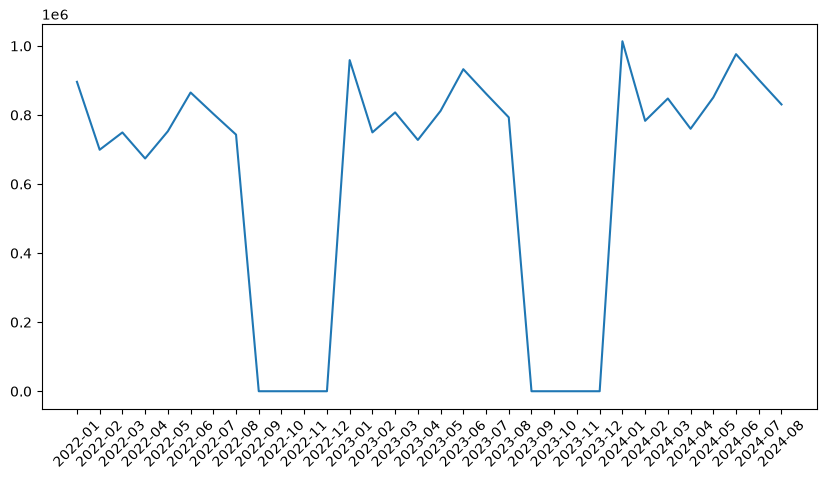

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(ventas_por_mes.index.astype(str), ventas_por_mes['Total_Ventas'])

plt.xticks(rotation=45)
plt.show()

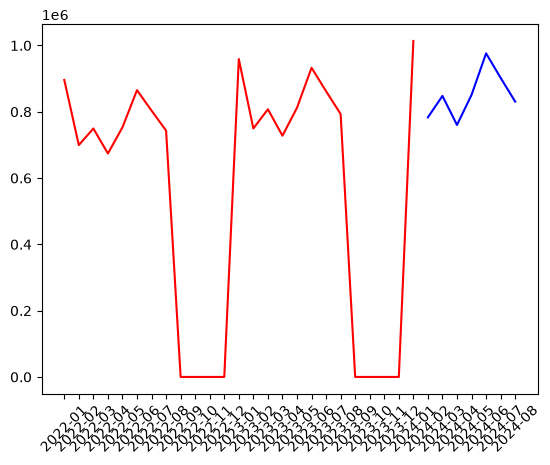

In [52]:
train = ventas_por_mes[:'2024-01']
test = ventas_por_mes['2024-02':]

plt.plot(train.index.astype(str), train.values, color='red')
plt.plot(test.index.astype(str), test.values, color='blue')

plt.xticks(rotation=45)
plt.show()

In [29]:
%pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.9/591.9 kB 3.0 MB/s eta 0:00:00-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 4.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 4.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 4.3 MB/s eta 0:00:00 0:00:01

[notice] A new release of pip is available: 24.2 -> 26.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [54]:
from pmdarima import auto_arima

model = auto_arima(train, seasonal=False)

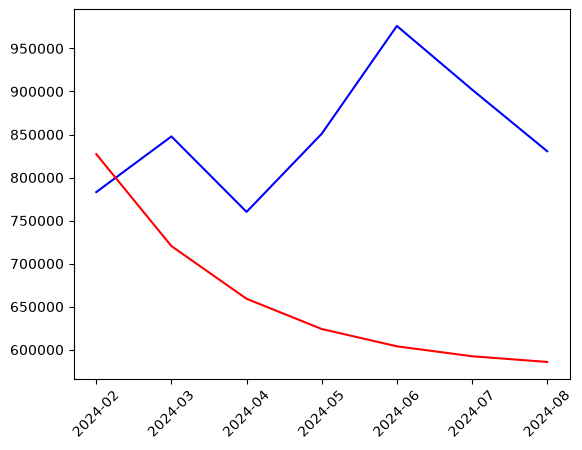

In [55]:
predicciones = model.predict(n_periods=len(test))

serie_predicciones = pd.Series(predicciones, index=test.index)

plt.plot(test.index.astype(str), test.values, color='blue')
plt.plot(serie_predicciones.index.astype(str), serie_predicciones.values, color='red')

plt.xticks(rotation=45)
plt.show()  